# Brain Tumor Classification — Transfer Learning Under Low-Data Regimes
### PyTorch Implementation | EfficientNet-B0 | TEI Metric
**Paper:** *Cross-Domain Transfer Learning for Brain Tumor Classification Under Limited MRI Data Regimes*

---
**Classes:** Glioma | Meningioma | Pituitary Tumor | No Tumor  
**Dataset:** Masoud Nickparvar — Brain Tumor MRI Dataset (Kaggle) — 7,200 balanced images  
**Backbone:** EfficientNet-B0 (ImageNet pretrained vs Scratch)  
**Data Fractions:** 5%, 10%, 20%, 30%, 50%, 100%  
**Version:** V2 — Focal Loss + Cosine LR + Gradual Unfreeze + High-Quality Figures

## 1. Install & Import Libraries

In [1]:
# !pip install torch torchvision timm scikit-learn matplotlib seaborn pandas tqdm kagglehub

import os
import random
import math
import csv
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from copy import deepcopy
from datetime import datetime
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import timm
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedShuffleSplit

# ── Reproducibility ──
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")

Device  : cuda
PyTorch : 2.7.1+cu118
timm    : 1.0.27


## 2. Configuration

In [2]:
# ══════════════════════════════════════════════════════
#                    CONFIGURATION
# ══════════════════════════════════════════════════════

# ── Dataset path (Masoud Nickparvar — 7,200 balanced images) ──
# After downloading from Kaggle, set this to your local path:
# kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
DATA_DIR        = "./data/brain_tumor_mri"   # <-- update this path

IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_CLASSES     = 4
EPOCHS          = 60
PATIENCE        = 12

# Learning rates
LR_HEAD         = 1e-3        # Stage 1: head only
LR_BACKBONE_S2  = 1e-4        # Stage 2: top 2 blocks
LR_BACKBONE_S3  = 1e-5        # Stage 3: full model

LABEL_SMOOTHING = 0.1
FOCAL_GAMMA     = 2.0         # Focal loss gamma
FOCAL_ALPHA     = 0.25        # Focal loss alpha

NUM_SEEDS       = 3
DATA_FRACTIONS  = [0.05, 0.10, 0.20, 0.30, 0.50, 1.00]
CLASS_NAMES     = ["glioma", "meningioma", "notumor", "pituitary"]
CLASS_DISPLAY   = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# ── Output directories — all PNGs saved here ──
RESULTS_DIR     = Path("./results")
FIGURES_DIR     = RESULTS_DIR / "figures"
EPOCH_CKPT_DIR  = RESULTS_DIR / "epoch_ckpts"
MODELS_DIR      = RESULTS_DIR / "models"

for d in [RESULTS_DIR, FIGURES_DIR, EPOCH_CKPT_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE = RESULTS_DIR / "checkpoint.csv"

# ── Matplotlib global style for publication-quality figures ──
matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})

# ── Color palette ──
COLOR_FT      = '#2C5F8A'   # pretrained (blue)
COLOR_SCR     = '#E05C2A'   # scratch (orange)
COLOR_THRESH  = '#27AE60'   # threshold (green)
CLASS_COLORS  = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

print("Configuration loaded.")
print(f"Dataset        : {DATA_DIR}")
print(f"Total experiments: {len(DATA_FRACTIONS) * 2 * NUM_SEEDS}  "
      f"(fractions × [pretrained, scratch] × seeds)")
print(f"Figures saved to: {FIGURES_DIR}")

Configuration loaded.
Dataset        : ./data/brain_tumor_mri
Total experiments: 36  (fractions × [pretrained, scratch] × seeds)
Figures saved to: results\figures


## 3. Download Dataset

In [3]:
# ── Option A: kagglehub (recommended) ──
# import kagglehub
# path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
# DATA_DIR = path
# print("Downloaded to:", path)

# ── Option B: Manual ──
# kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
# unzip brain-tumor-mri-dataset.zip -d ./data/brain_tumor_mri/

# ── Verify structure ──
print("Dataset structure:")
print("=" * 45)
total = {"Training": 0, "Testing": 0}
class_counts = {}
for split in ["Training", "Testing"]:
    split_path = Path(DATA_DIR) / split
    if split_path.exists():
        for cls in sorted(split_path.iterdir()):
            n = len(list(cls.glob("*.jpg")) + list(cls.glob("*.png")))
            print(f"  {split}/{cls.name}: {n} images")
            total[split] += n
            class_counts[f"{split}/{cls.name}"] = n
        print(f"  {split} TOTAL: {total[split]}")
        print()
    else:
        print(f"  {split_path} not found — please download dataset first")
print(f"Grand total: {sum(total.values())} images")

Dataset structure:
  Training/glioma: 1400 images
  Training/meningioma: 1400 images
  Training/notumor: 1400 images
  Training/pituitary: 1400 images
  Training TOTAL: 5600

  Testing/glioma: 400 images
  Testing/meningioma: 400 images
  Testing/notumor: 400 images
  Testing/pituitary: 400 images
  Testing TOTAL: 1600

Grand total: 7200 images


## 4. Initial Data Visualization (Publication Quality)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 0A: Class Distribution — Training vs Testing
# ═══════════════════════════════════════════════════════════════

train_counts = []
test_counts  = []
for cls in CLASS_NAMES:
    tr_path = Path(DATA_DIR) / "Training" / cls
    te_path = Path(DATA_DIR) / "Testing"  / cls
    train_counts.append(len(list(tr_path.glob("*.jpg")) + list(tr_path.glob("*.png"))) if tr_path.exists() else 0)
    test_counts.append (len(list(te_path.glob("*.jpg")) + list(te_path.glob("*.png"))) if te_path.exists() else 0)

x    = np.arange(len(CLASS_NAMES))
w    = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Brain Tumor MRI Dataset — Class Distribution Analysis",
             fontsize=15, fontweight='bold', y=1.02)

# Bar chart
ax = axes[0]
b1 = ax.bar(x - w/2, train_counts, w, label='Training', color=COLOR_FT,   alpha=0.85, edgecolor='white', linewidth=1.2)
b2 = ax.bar(x + w/2, test_counts,  w, label='Testing',  color=COLOR_SCR,  alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, val in zip(b1, train_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(b2, test_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_DISPLAY, fontsize=11)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Class Distribution: Training vs Testing", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(train_counts) * 1.2)

# Pie chart — training split
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    train_counts,
    labels=CLASS_DISPLAY,
    colors=CLASS_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax.set_title("Training Set Class Proportion", fontsize=13, fontweight='bold')

plt.tight_layout()
save_path = FIGURES_DIR / "fig0a_class_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

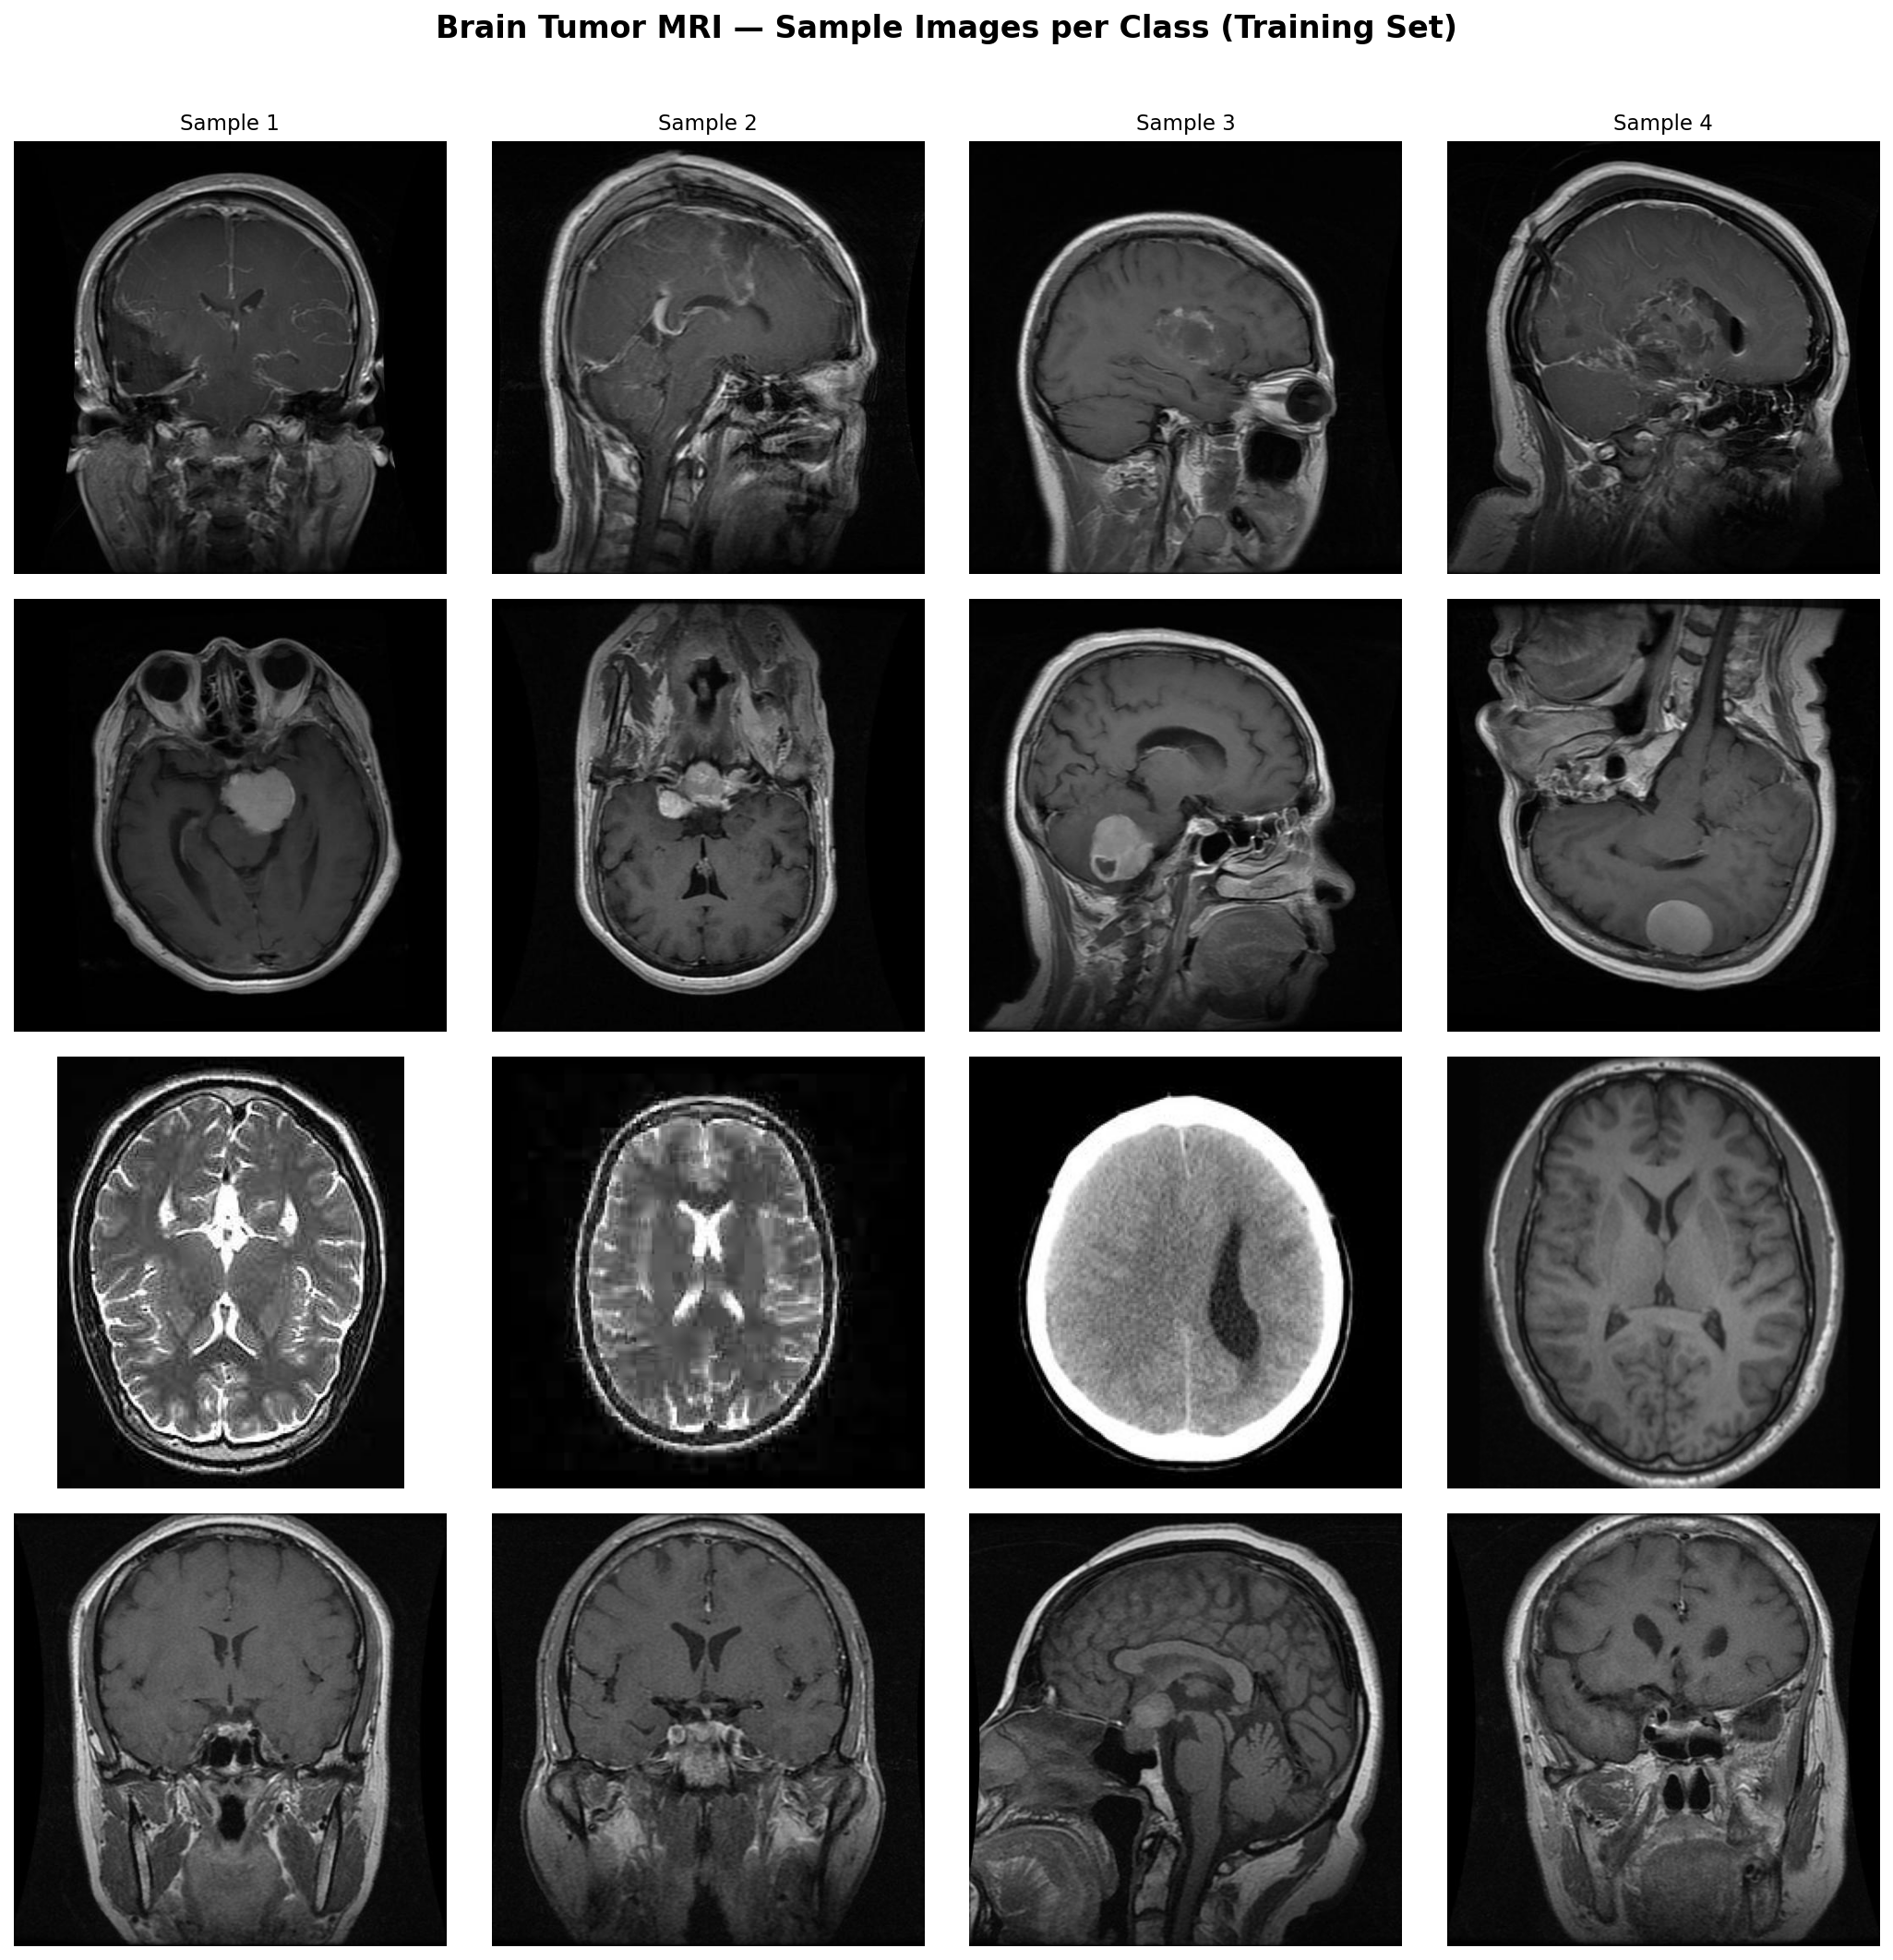

Saved: results\figures\fig0b_sample_images.png


In [5]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 0B: Sample MRI Images — 4 classes × 4 samples
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Brain Tumor MRI — Sample Images per Class (Training Set)",
             fontsize=16, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = Path(DATA_DIR) / "Training" / cls
    imgs = (list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png")))[:4]
    for col_idx, img_path in enumerate(imgs):
        ax = axes[row_idx, col_idx]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(CLASS_DISPLAY[row_idx], fontsize=13, fontweight='bold',
                          rotation=90, labelpad=10,
                          color=CLASS_COLORS[row_idx])
            ax.yaxis.set_label_coords(-0.1, 0.5)
        if row_idx == 0:
            ax.set_title(f"Sample {col_idx+1}", fontsize=11)

# Add colored border per class row
for row_idx in range(4):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        for spine in ax.spines.values():
            spine.set_edgecolor(CLASS_COLORS[row_idx])
            spine.set_linewidth(2.5)
            spine.set_visible(True)

plt.tight_layout()
save_path = FIGURES_DIR / "fig0b_sample_images.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 0C: Pixel Intensity Distribution per Class
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle("Pixel Intensity Distributions by Class (Grayscale)",
             fontsize=15, fontweight='bold')

N_SAMPLE = 50   # images per class to sample

for idx, cls in enumerate(CLASS_NAMES):
    cls_path  = Path(DATA_DIR) / "Training" / cls
    img_paths = (list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png")))[:N_SAMPLE]
    all_pixels = []
    for ip in img_paths:
        arr = np.array(Image.open(ip).convert("L").resize((128, 128))).flatten()
        all_pixels.extend(arr.tolist())
    ax = axes[idx]
    ax.hist(all_pixels, bins=64, color=CLASS_COLORS[idx], alpha=0.8,
            edgecolor='white', linewidth=0.5, density=True)
    ax.set_title(CLASS_DISPLAY[idx], fontsize=13, fontweight='bold',
                 color=CLASS_COLORS[idx])
    ax.set_xlabel("Pixel Intensity (0–255)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Density", fontsize=11)
    ax.set_xlim(0, 255)
    mean_val = np.mean(all_pixels)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={mean_val:.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
save_path = FIGURES_DIR / "fig0c_pixel_intensity.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 0D: Data Fraction Summary — Training Samples per Experiment
# ═══════════════════════════════════════════════════════════════

# Approximate: 85% of training set used for train, 15% val
total_train = sum(train_counts)
base_train  = int(total_train * 0.85)
frac_samples = [int(base_train * f) for f in DATA_FRACTIONS]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [f"{int(f*100)}%" for f in DATA_FRACTIONS],
    frac_samples,
    color=[plt.cm.Blues(0.4 + 0.6 * i / len(DATA_FRACTIONS)) for i in range(len(DATA_FRACTIONS))],
    edgecolor='white', linewidth=1.5, width=0.6
)
for bar, val in zip(bars, frac_samples):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel("Training Data Fraction", fontsize=12)
ax.set_ylabel("Number of Training Samples", fontsize=12)
ax.set_title("Experiment Design: Training Samples at Each Data Fraction",
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(frac_samples) * 1.18)

# Annotate total dataset size
ax.axhline(base_train, color=COLOR_THRESH, linestyle='--', linewidth=1.5,
           label=f'Full training set ({base_train:,} samples)')
ax.legend(fontsize=11)

plt.tight_layout()
save_path = FIGURES_DIR / "fig0d_fraction_design.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## 5. Transforms & Dataset

In [8]:
# ── Normalization stats ──
# Using ImageNet stats (standard for transfer learning from ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Full augmentation (100% data fraction) ──
train_transform_full = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])

# ── Basic augmentation (low-data fractions) ──
train_transform_basic = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Val/Test transform ──
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Load full datasets ──
full_train_dataset = ImageFolder(
    root=os.path.join(DATA_DIR, "Training"),
    transform=train_transform_basic
)
test_dataset = ImageFolder(
    root=os.path.join(DATA_DIR, "Testing"),
    transform=val_test_transform
)

print(f"Total training images : {len(full_train_dataset)}")
print(f"Total test images     : {len(test_dataset)}")
print(f"Classes               : {full_train_dataset.classes}")
print(f"Class to index        : {full_train_dataset.class_to_idx}")

Total training images : 5600
Total test images     : 1600
Classes               : ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index        : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 6. Stratified Train/Val Split & Fraction Sampling

In [9]:
def get_stratified_val_split(dataset, val_ratio=0.15, seed=42):
    labels = [dataset.targets[i] for i in range(len(dataset))]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(sss.split(range(len(dataset)), labels))
    return list(train_idx), list(val_idx)

def get_fraction_subset(dataset, indices, fraction, seed=42):
    if fraction >= 1.0:
        return indices
    labels = [dataset.targets[i] for i in indices]
    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=(1.0 - fraction), random_state=seed
    )
    keep_local, _ = next(sss.split(range(len(indices)), labels))
    return [indices[i] for i in keep_local]

# Create base train/val split
base_train_idx, val_idx = get_stratified_val_split(full_train_dataset, val_ratio=0.15)
print(f"Base train indices : {len(base_train_idx)}")
print(f"Val indices        : {len(val_idx)}")
print(f"Test images        : {len(test_dataset)}")

print("\nFraction → N training samples:")
for f in DATA_FRACTIONS:
    n = len(get_fraction_subset(full_train_dataset, base_train_idx, f))
    print(f"  {int(f*100):>4}%  →  {n:>5} samples")

Base train indices : 4760
Val indices        : 840
Test images        : 1600

Fraction → N training samples:
     5%  →    238 samples
    10%  →    476 samples
    20%  →    952 samples
    30%  →   1428 samples
    50%  →   2380 samples
   100%  →   4760 samples


## 7. Focal Loss

In [10]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    Focuses training on hard-to-classify examples.
    """
    def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.gamma           = gamma
        self.alpha           = alpha
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, inputs, targets):
        # Label smoothing
        n_classes = inputs.size(1)
        with torch.no_grad():
            smooth_targets = torch.full_like(inputs, self.label_smoothing / n_classes)
            smooth_targets.scatter_(1, targets.unsqueeze(1),
                                    1.0 - self.label_smoothing + self.label_smoothing / n_classes)

        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)

        # p_t for each sample (probability of correct class)
        p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal weight
        focal_weight = self.alpha * (1.0 - p_t) ** self.gamma

        # Cross entropy with smooth targets
        ce_loss = -(smooth_targets * log_probs).sum(dim=1)
        loss    = focal_weight * ce_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

# Test
_dummy_in  = torch.randn(8, 4)
_dummy_tgt = torch.randint(0, 4, (8,))
_fl = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING)
print(f"FocalLoss test : {_fl(_dummy_in, _dummy_tgt):.4f}")
print("FocalLoss defined.")

FocalLoss test : 0.4293
FocalLoss defined.


## 8. Model Architecture

In [11]:
def build_model(pretrained=True, num_classes=NUM_CLASSES):
    """
    EfficientNet-B0 with custom classification head.
    Head: Dropout(0.3) → Linear(1280, 512) → SiLU → BN → Dropout(0.3) → Linear(512, 4)
    """
    model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
    in_features = model.num_features  # 1280

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model

# ── Freeze/Unfreeze helpers ──
def freeze_backbone(model):
    """Freeze all except classifier head."""
    for name, param in model.named_parameters():
        param.requires_grad = ('classifier' in name)

def unfreeze_top_blocks(model, num_blocks=2):
    """Unfreeze last N blocks of EfficientNet backbone."""
    blocks = list(model.blocks.children())
    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True

def unfreeze_all(model):
    """Stage 3: unfreeze entire model."""
    for param in model.parameters():
        param.requires_grad = True

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick test
m = build_model(pretrained=False)
freeze_backbone(m)
print(f"Total parameters       : {sum(p.numel() for p in m.parameters()):,}")
print(f"Trainable (head only)  : {count_trainable(m):,}")
unfreeze_top_blocks(m, 2)
print(f"Trainable (+ 2 blocks) : {count_trainable(m):,}")
unfreeze_all(m)
print(f"Trainable (full model) : {count_trainable(m):,}")
del m

Total parameters       : 4,666,496
Trainable (head only)  : 658,948
Trainable (+ 2 blocks) : 3,402,528
Trainable (full model) : 4,666,496


## 9. Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, acc, f1, all_preds, all_labels


print("Training functions defined.")

Training functions defined.


## 10. Transfer Efficiency Index (TEI)

In [13]:
def compute_tei(acc_ft, acc_scratch, n_samples):
    """
    Transfer Efficiency Index (TEI)
        TEI = (Acc_ft - Acc_scratch) / log10(N)
    Negative TEI = negative transfer (scratch beats pretrained).
    """
    if n_samples <= 1:
        return 0.0
    return (acc_ft - acc_scratch) / math.log10(n_samples)

def interpret_tei(tei):
    if tei > 0.15:   return "Excellent transfer"
    elif tei > 0.10: return "Good transfer"
    elif tei > 0.05: return "Moderate transfer"
    elif tei > 0:    return "Weak transfer"
    else:            return "Negative transfer"

example = compute_tei(acc_ft=0.87, acc_scratch=0.60, n_samples=500)
print(f"Example TEI : {example:.4f}  — {interpret_tei(example)}")

Example TEI : 0.1000  — Good transfer


## 11. Checkpoint System (Power-Cut Safe)

In [14]:
CKPT_FIELDS = ["fraction", "mode", "seed", "test_acc", "test_f1"]

def run_key(fraction, mode, seed):
    return f"frac{int(fraction*100)}_{mode}_seed{seed}"

def is_completed(fraction, mode, seed):
    if not CHECKPOINT_FILE.exists():
        return False
    with open(CHECKPOINT_FILE) as f:
        return any(
            float(r["fraction"]) == fraction
            and r["mode"] == mode
            and int(r["seed"]) == seed
            for r in csv.DictReader(f)
        )

def load_result(fraction, mode, seed):
    with open(CHECKPOINT_FILE) as f:
        for r in csv.DictReader(f):
            if (float(r["fraction"]) == fraction
                    and r["mode"] == mode
                    and int(r["seed"]) == seed):
                return float(r["test_acc"]), float(r["test_f1"])

def save_result(fraction, mode, seed, acc, f1):
    write_header = not CHECKPOINT_FILE.exists()
    with open(CHECKPOINT_FILE, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=CKPT_FIELDS)
        if write_header:
            w.writeheader()
        w.writerow({"fraction": fraction, "mode": mode, "seed": seed,
                    "test_acc": acc, "test_f1": f1})

def save_epoch_ckpt(fraction, mode, seed, epoch, model, optimizer,
                    best_val_loss, best_weights, patience_counter,
                    history, stage):
    torch.save({
        "epoch":            epoch,
        "model_state":      model.state_dict(),
        "optimizer_state":  optimizer.state_dict(),
        "best_val_loss":    best_val_loss,
        "best_weights":     best_weights,
        "patience_counter": patience_counter,
        "history":          history,
        "stage":            stage,
    }, EPOCH_CKPT_DIR / f"{run_key(fraction, mode, seed)}.pt")

def load_epoch_ckpt(fraction, mode, seed, model, pretrained):
    path = EPOCH_CKPT_DIR / f"{run_key(fraction, mode, seed)}.pt"
    if not path.exists():
        return None
    try:
        ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    except Exception as e:
        print(f"  Corrupted checkpoint ({e}) — starting fresh")
        path.unlink()
        return None

    model.load_state_dict(ckpt["model_state"])
    stage = ckpt["stage"]

    if pretrained:
        if stage == 1:   freeze_backbone(model)
        elif stage == 2: unfreeze_top_blocks(model, 2)
        else:            unfreeze_all(model)

    trainable = [p for p in model.parameters() if p.requires_grad]
    head_ids  = {id(p) for p in model.classifier.parameters()}

    if pretrained and stage >= 2:
        optimizer = optim.AdamW([
            {"params": [p for p in trainable if id(p) in head_ids],     "lr": LR_HEAD},
            {"params": [p for p in trainable if id(p) not in head_ids], "lr": LR_BACKBONE_S2},
        ], weight_decay=1e-4)
    else:
        optimizer = optim.AdamW(trainable, lr=LR_HEAD, weight_decay=1e-4)

    try:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    except Exception:
        pass

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1)

    return (ckpt["epoch"] + 1, ckpt["best_val_loss"], ckpt["best_weights"],
            ckpt["patience_counter"], ckpt["history"], stage, optimizer, scheduler)

completed_count = 0
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE) as f:
        completed_count = sum(1 for _ in csv.DictReader(f))
total_runs = len(DATA_FRACTIONS) * 2 * NUM_SEEDS
print(f"Checkpoint system ready.")
print(f"Completed so far: {completed_count} / {total_runs} runs")

Checkpoint system ready.
Completed so far: 41 / 36 runs


## 12. Training Function — 3-Stage Gradual Unfreeze + Resume

In [15]:
def train_with_resume(model, train_loader, val_loader, test_loader,
                      pretrained, fraction, mode, seed, n_train):
    """
    3-Stage training with per-epoch checkpoint saves:
      Stage 1 (epochs 1–10)  : freeze backbone, train head only
      Stage 2 (epochs 11–25) : unfreeze top 2 blocks
      Stage 3 (epoch 26+)    : unfreeze full model (very low LR)
    """
    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=FOCAL_ALPHA,
        label_smoothing=LABEL_SMOOTHING
    )

    resumed = load_epoch_ckpt(fraction, mode, seed, model, pretrained)
    if resumed:
        start_epoch, best_val_loss, best_weights, patience_counter, \
            history, stage, optimizer, scheduler = resumed
        print(f"  Resuming from epoch {start_epoch}  "
              f"(stage={stage}, best_val_loss={best_val_loss:.4f}, patience={patience_counter})")
    else:
        start_epoch      = 1
        best_val_loss    = float("inf")
        best_weights     = None
        patience_counter = 0
        stage            = 1
        history = {"train_loss": [], "val_loss": [],
                   "train_acc":  [], "val_acc":  [],
                   "val_f1":     [], "lr":        []}
        if pretrained:
            freeze_backbone(model)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR_HEAD, weight_decay=1e-4
        )
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=1
        )

    for epoch in range(start_epoch, EPOCHS + 1):

        # ── Stage transitions ──
        if pretrained:
            if epoch == 11 and stage < 2:
                unfreeze_top_blocks(model, num_blocks=2)
                trainable = [p for p in model.parameters() if p.requires_grad]
                head_ids  = {id(p) for p in model.classifier.parameters()}
                optimizer = optim.AdamW([
                    {"params": [p for p in trainable if id(p) in head_ids],     "lr": LR_HEAD},
                    {"params": [p for p in trainable if id(p) not in head_ids], "lr": LR_BACKBONE_S2},
                ], weight_decay=1e-4)
                scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
                    optimizer, T_0=10, T_mult=1
                )
                stage = 2
                print(f"  ▶ Stage 2 unlocked at epoch {epoch} "
                      f"(top 2 blocks, trainable={count_trainable(model):,})")

            elif epoch == 26 and stage < 3:
                unfreeze_all(model)
                trainable = [p for p in model.parameters() if p.requires_grad]
                head_ids  = {id(p) for p in model.classifier.parameters()}
                optimizer = optim.AdamW([
                    {"params": [p for p in trainable if id(p) in head_ids],     "lr": LR_BACKBONE_S2},
                    {"params": [p for p in trainable if id(p) not in head_ids], "lr": LR_BACKBONE_S3},
                ], weight_decay=1e-4)
                scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
                    optimizer, T_0=10, T_mult=1
                )
                stage = 3
                print(f"  ▶ Stage 3 unlocked at epoch {epoch} "
                      f"(full model, trainable={count_trainable(model):,})")

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
        history["lr"].append(current_lr)

        improved = vl_loss < best_val_loss
        if improved:
            best_val_loss    = vl_loss
            best_weights     = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # Save after every epoch — safe to interrupt
        save_epoch_ckpt(fraction, mode, seed, epoch, model, optimizer,
                        best_val_loss, best_weights, patience_counter, history, stage)

        marker = "★" if improved else f"pat={patience_counter}/{PATIENCE}"
        print(f"  Ep {epoch:>3}/{EPOCHS}  s{stage}  "
              f"tr={tr_loss:.4f}  vl={vl_loss:.4f}  "
              f"vl_acc={vl_acc*100:.1f}%  vl_f1={vl_f1:.4f}  "
              f"lr={current_lr:.2e}  {marker}")

        if patience_counter >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_weights)
    _, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, DEVICE)
    return model, history, test_acc, test_f1, preds, labels

print("train_with_resume() defined.")

train_with_resume() defined.


## 13. run_fraction() Helper

In [16]:
def run_fraction(fraction):
    """Run pretrained + scratch × 3 seeds for one data fraction. Resumes automatically."""
    fraction_results = []
    pct = int(fraction * 100)
    print(f"\n{'='*65}")
    print(f"  FRACTION: {pct}%  "
          f"({len(get_fraction_subset(full_train_dataset, base_train_idx, fraction))} samples)")
    print(f"{'='*65}")

    for pretrained in [True, False]:
        mode = "pretrained" if pretrained else "scratch"
        seed_accs, seed_f1s = [], []
        best_preds = best_labels = best_history = None

        for seed in range(NUM_SEEDS):
            if is_completed(fraction, mode, seed):
                acc, f1 = load_result(fraction, mode, seed)
                seed_accs.append(acc)
                seed_f1s.append(f1)
                print(f"  [{mode}] seed={seed}  LOADED   Acc={acc:.4f}  F1={f1:.4f}")
                continue

            set_seed(seed)
            print(f"\n  [{mode}] seed={seed}  TRAINING ...")

            train_idx = get_fraction_subset(full_train_dataset, base_train_idx, fraction, seed=seed)
            n_train   = len(train_idx)

            # Full augmentation at 100%, basic otherwise
            full_train_dataset.transform = (
                train_transform_full if fraction == 1.0 else train_transform_basic
            )
            val_dataset_copy = ImageFolder(
                root=os.path.join(DATA_DIR, "Training"),
                transform=val_test_transform
            )

            train_subset = Subset(full_train_dataset, train_idx)
            val_subset   = Subset(val_dataset_copy, val_idx)

            pin = DEVICE.type == "cuda"
            train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE,
                                      shuffle=True,  num_workers=2, pin_memory=pin)
            val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=2, pin_memory=pin)
            test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=2, pin_memory=pin)

            model = build_model(pretrained=pretrained).to(DEVICE)
            model, history, test_acc, test_f1, preds, labels = train_with_resume(
                model, train_loader, val_loader, test_loader,
                pretrained, fraction, mode, seed, n_train
            )

            seed_accs.append(test_acc)
            seed_f1s.append(test_f1)
            print(f"  [{mode}] seed={seed}  DONE     Acc={test_acc:.4f}  F1={test_f1:.4f}")

            save_result(fraction, mode, seed, test_acc, test_f1)

            if seed == 0:
                best_preds, best_labels, best_history = preds, labels, history
                torch.save(model.state_dict(),
                           MODELS_DIR / f"model_frac{pct}_{mode}.pt")

        n_val    = len(get_fraction_subset(full_train_dataset, base_train_idx, fraction))
        mean_acc = np.mean(seed_accs)
        std_acc  = np.std(seed_accs)
        mean_f1  = np.mean(seed_f1s)
        std_f1   = np.std(seed_f1s)
        print(f"\n  [{mode}] mean_acc={mean_acc:.4f} ± {std_acc:.4f}  "
              f"mean_f1={mean_f1:.4f} ± {std_f1:.4f}")

        fraction_results.append({
            "fraction":     fraction,
            "fraction_pct": pct,
            "mode":         mode,
            "pretrained":   pretrained,
            "n_train":      n_val,
            "mean_acc":     mean_acc,
            "std_acc":      std_acc,
            "mean_f1":      mean_f1,
            "std_f1":       std_f1,
            "preds":        best_preds,
            "labels":       best_labels,
            "history":      best_history,
        })

    return fraction_results

print("run_fraction() defined.")

run_fraction() defined.


## 14. Run Experiments — One Cell Per Fraction

> Run each cell independently. If battery dies, re-run the same cell — resumes from last saved epoch automatically.

In [17]:
# ── 5% Data ──
results_5pct = run_fraction(0.05)


  FRACTION: 5%  (238 samples)
  [pretrained] seed=0  LOADED   Acc=0.7837  F1=0.7759
  [pretrained] seed=1  LOADED   Acc=0.7706  F1=0.7625
  [pretrained] seed=2  LOADED   Acc=0.7937  F1=0.7851

  [pretrained] mean_acc=0.7827 ± 0.0095  mean_f1=0.7745 ± 0.0093
  [scratch] seed=0  LOADED   Acc=0.6713  F1=0.6571
  [scratch] seed=1  LOADED   Acc=0.6556  F1=0.6290
  [scratch] seed=2  LOADED   Acc=0.6787  F1=0.6686

  [scratch] mean_acc=0.6685 ± 0.0096  mean_f1=0.6516 ± 0.0166


In [18]:
# ── 10% Data ──
results_10pct = run_fraction(0.10)


  FRACTION: 10%  (476 samples)
  [pretrained] seed=0  LOADED   Acc=0.8081  F1=0.8037
  [pretrained] seed=1  LOADED   Acc=0.7931  F1=0.7847
  [pretrained] seed=2  LOADED   Acc=0.8394  F1=0.8361

  [pretrained] mean_acc=0.8135 ± 0.0193  mean_f1=0.8082 ± 0.0212
  [scratch] seed=0  LOADED   Acc=0.7969  F1=0.7891
  [scratch] seed=1  LOADED   Acc=0.7887  F1=0.7789
  [scratch] seed=2  LOADED   Acc=0.7775  F1=0.7691

  [scratch] mean_acc=0.7877 ± 0.0079  mean_f1=0.7790 ± 0.0082


In [19]:
# ── 20% Data ──
results_20pct = run_fraction(0.20)


  FRACTION: 20%  (952 samples)
  [pretrained] seed=0  LOADED   Acc=0.8681  F1=0.8658
  [pretrained] seed=1  LOADED   Acc=0.8275  F1=0.8243
  [pretrained] seed=2  LOADED   Acc=0.8712  F1=0.8672

  [pretrained] mean_acc=0.8556 ± 0.0199  mean_f1=0.8525 ± 0.0199
  [scratch] seed=0  LOADED   Acc=0.8500  F1=0.8468
  [scratch] seed=1  LOADED   Acc=0.8237  F1=0.8184
  [scratch] seed=2  LOADED   Acc=0.8106  F1=0.8046

  [scratch] mean_acc=0.8281 ± 0.0164  mean_f1=0.8233 ± 0.0176


In [20]:
# ── 30% Data ──
results_30pct = run_fraction(0.30)


  FRACTION: 30%  (1428 samples)
  [pretrained] seed=0  LOADED   Acc=0.9150  F1=0.9129
  [pretrained] seed=1  LOADED   Acc=0.8938  F1=0.8904
  [pretrained] seed=2  LOADED   Acc=0.8944  F1=0.8913

  [pretrained] mean_acc=0.9010 ± 0.0099  mean_f1=0.8982 ± 0.0104
  [scratch] seed=0  LOADED   Acc=0.9025  F1=0.9002
  [scratch] seed=1  LOADED   Acc=0.8956  F1=0.8931
  [scratch] seed=2  LOADED   Acc=0.8931  F1=0.8913

  [scratch] mean_acc=0.8971 ± 0.0040  mean_f1=0.8949 ± 0.0038


In [21]:
# ── 50% Data ──
results_50pct = run_fraction(0.50)


  FRACTION: 50%  (2380 samples)
  [pretrained] seed=0  LOADED   Acc=0.9294  F1=0.9276
  [pretrained] seed=1  LOADED   Acc=0.9275  F1=0.9259
  [pretrained] seed=2  LOADED   Acc=0.9200  F1=0.9177

  [pretrained] mean_acc=0.9256 ± 0.0041  mean_f1=0.9237 ± 0.0044
  [scratch] seed=0  LOADED   Acc=0.9137  F1=0.9117
  [scratch] seed=1  LOADED   Acc=0.9044  F1=0.9017
  [scratch] seed=2  LOADED   Acc=0.9137  F1=0.9117

  [scratch] mean_acc=0.9106 ± 0.0044  mean_f1=0.9083 ± 0.0047


In [22]:
# ── 100% Data ──
results_100pct = run_fraction(1.00)


  FRACTION: 100%  (4760 samples)
  [pretrained] seed=0  LOADED   Acc=0.9381  F1=0.9369
  [pretrained] seed=1  LOADED   Acc=0.9437  F1=0.9429
  [pretrained] seed=2  LOADED   Acc=0.9519  F1=0.9510

  [pretrained] mean_acc=0.9446 ± 0.0056  mean_f1=0.9436 ± 0.0058
  [scratch] seed=0  LOADED   Acc=0.9231  F1=0.9223
  [scratch] seed=1  LOADED   Acc=0.9481  F1=0.9474
  [scratch] seed=2  LOADED   Acc=0.9394  F1=0.9384

  [scratch] mean_acc=0.9369 ± 0.0104  mean_f1=0.9360 ± 0.0104


## 15. Collect All Results & Compute TEI

In [23]:
results = (
    results_5pct + results_10pct + results_20pct +
    results_30pct + results_50pct + results_100pct
)
print(f"Total result entries: {len(results)}  (expected 12 = 6 fractions × 2 modes)")

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['preds', 'labels', 'history']}
    for r in results
])

# Pivot for TEI
pt = df.pivot_table(
    index='fraction', columns='mode',
    values=['mean_acc', 'mean_f1', 'n_train', 'std_acc', 'std_f1']
).reset_index()
pt.columns = ['_'.join(c).strip('_') for c in pt.columns]

pt['TEI'] = pt.apply(
    lambda row: compute_tei(
        acc_ft      = row['mean_acc_pretrained'],
        acc_scratch = row['mean_acc_scratch'],
        n_samples   = int(row['n_train_pretrained'])
    ), axis=1
)
pt['TEI_interpretation'] = pt['TEI'].apply(interpret_tei)
pt['fraction_pct']       = (pt['fraction'] * 100).astype(int)

# Save CSVs
pt.to_csv(RESULTS_DIR / "tei_results.csv", index=False)
df.to_csv(RESULTS_DIR / "all_results.csv", index=False)

# Print summary
cols = ['fraction_pct', 'n_train_pretrained',
        'mean_acc_pretrained', 'std_acc_pretrained',
        'mean_acc_scratch',    'std_acc_scratch',
        'mean_f1_pretrained',  'std_f1_pretrained',
        'TEI', 'TEI_interpretation']
print(pt[cols].to_string(index=False))

Total result entries: 12  (expected 12 = 6 fractions × 2 modes)
 fraction_pct  n_train_pretrained  mean_acc_pretrained  std_acc_pretrained  mean_acc_scratch  std_acc_scratch  mean_f1_pretrained  std_f1_pretrained      TEI TEI_interpretation
            5               238.0             0.782708            0.009469          0.668542         0.009633            0.774506           0.009294 0.048038      Weak transfer
           10               476.0             0.813542            0.019266          0.787708         0.007944            0.808185           0.021210 0.009648      Weak transfer
           20               952.0             0.855625            0.019928          0.828125         0.016370            0.852456           0.019895 0.009232      Weak transfer
           30              1428.0             0.901042            0.009873          0.897083         0.003964            0.898218           0.010403 0.001255      Weak transfer
           50              2380.0             0.925

## 16. Figure 1 — Main Results (Publication Quality)

In [ ]:
fracs = pt['fraction_pct'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Transfer Learning Under Low-Data Regimes — Brain Tumor MRI Classification\n"
    "EfficientNet-B0 | 4-Class | Masoud Nickparvar Dataset (7,200 images)",
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Accuracy vs Fraction ──
ax = axes[0]
ax.plot(fracs, pt['mean_acc_pretrained'] * 100, 'o-',
        color=COLOR_FT, linewidth=2.5, markersize=9, label='Fine-tuned (ImageNet)', zorder=3)
ax.fill_between(
    fracs,
    (pt['mean_acc_pretrained'] - pt['std_acc_pretrained']) * 100,
    (pt['mean_acc_pretrained'] + pt['std_acc_pretrained']) * 100,
    alpha=0.15, color=COLOR_FT
)
ax.plot(fracs, pt['mean_acc_scratch'] * 100, 's--',
        color=COLOR_SCR, linewidth=2.5, markersize=9, label='From Scratch', zorder=3)
ax.fill_between(
    fracs,
    (pt['mean_acc_scratch'] - pt['std_acc_scratch']) * 100,
    (pt['mean_acc_scratch'] + pt['std_acc_scratch']) * 100,
    alpha=0.15, color=COLOR_SCR
)
ax.axhline(y=85, color=COLOR_THRESH, linestyle=':', linewidth=2,
           label='Clinical threshold (85%)')
ax.set_xlabel("Training Data Fraction (%)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Accuracy vs Data Fraction", fontweight='bold')
ax.legend()
ax.set_xticks(fracs)
ax.set_ylim(0, 105)

# ── Plot 2: TEI vs Fraction ──
ax = axes[1]
bar_colors = [
    '#2ECC71' if t > 0.10 else
    '#F39C12' if t > 0.05 else
    '#E74C3C'
    for t in pt['TEI'].values
]
bars = ax.bar(fracs, pt['TEI'].values, color=bar_colors,
              edgecolor='white', linewidth=1.5, width=6, zorder=3)
ax.axhline(y=0.10, color='#2ECC71', linestyle='--', linewidth=1.8,
           label='Good transfer (0.10)')
ax.axhline(y=0.05, color='#F39C12', linestyle='--', linewidth=1.8,
           label='Moderate transfer (0.05)')
ax.axhline(y=0.00, color='black',   linestyle='-',  linewidth=0.8)
for bar, val in zip(bars, pt['TEI'].values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel("Training Data Fraction (%)")
ax.set_ylabel("TEI")
ax.set_title("Transfer Efficiency Index (TEI)", fontweight='bold')
ax.legend()
ax.set_xticks(fracs)

# ── Plot 3: Macro F1 vs Fraction ──
ax = axes[2]
ax.plot(fracs, pt['mean_f1_pretrained'], 'o-',
        color=COLOR_FT, linewidth=2.5, markersize=9, label='Fine-tuned (ImageNet)', zorder=3)
ax.fill_between(
    fracs,
    pt['mean_f1_pretrained'] - pt['std_f1_pretrained'],
    pt['mean_f1_pretrained'] + pt['std_f1_pretrained'],
    alpha=0.15, color=COLOR_FT
)
ax.plot(fracs, pt['mean_f1_scratch'], 's--',
        color=COLOR_SCR, linewidth=2.5, markersize=9, label='From Scratch', zorder=3)
ax.fill_between(
    fracs,
    pt['mean_f1_scratch'] - pt['std_f1_scratch'],
    pt['mean_f1_scratch'] + pt['std_f1_scratch'],
    alpha=0.15, color=COLOR_SCR
)
ax.axhline(y=0.85, color=COLOR_THRESH, linestyle=':', linewidth=2,
           label='Clinical threshold (0.85)')
ax.set_xlabel("Training Data Fraction (%)")
ax.set_ylabel("Macro F1 Score")
ax.set_title("Macro F1 vs Data Fraction", fontweight='bold')
ax.legend()
ax.set_xticks(fracs)
ax.set_ylim(0, 1.05)

plt.tight_layout()
save_path = FIGURES_DIR / "fig1_main_results.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [25]:
from pathlib import Path

print("Files in RESULTS_DIR:")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

print("\nFiles in epoch checkpoint dir (if it exists):")
ckpt_dir = RESULTS_DIR / "epoch_ckpts"
if ckpt_dir.exists():
    for f in sorted(ckpt_dir.iterdir()):
        print(f"  {f.name}")
else:
    print("  (no epoch_ckpts folder)")

Files in RESULTS_DIR:
  all_results.csv
  checkpoint.csv
  epoch_ckpts
  figure2_confusion_matrices.png
  figure_attention_evolution.png
  figures
  models
  results_summary.json
  tei_results.csv
  tei_summary.csv

Files in epoch checkpoint dir (if it exists):
  frac100_pretrained_seed0.pt
  frac100_pretrained_seed1.pt
  frac100_pretrained_seed2.pt
  frac100_scratch_seed0.pt
  frac100_scratch_seed1.pt
  frac100_scratch_seed2.pt
  frac10_pretrained_seed0.pt
  frac10_pretrained_seed1.pt
  frac10_pretrained_seed2.pt
  frac10_scratch_seed0.pt
  frac10_scratch_seed1.pt
  frac10_scratch_seed2.pt
  frac20_pretrained_seed0.pt
  frac20_pretrained_seed1.pt
  frac20_pretrained_seed2.pt
  frac20_scratch_seed0.pt
  frac20_scratch_seed1.pt
  frac20_scratch_seed2.pt
  frac30_pretrained_seed0.pt
  frac30_pretrained_seed1.pt
  frac30_pretrained_seed2.pt
  frac30_scratch_seed0.pt
  frac30_scratch_seed1.pt
  frac30_scratch_seed2.pt
  frac50_pretrained_seed0.pt
  frac50_pretrained_seed1.pt
  frac50_pretr

## 17. Figure 2 — Confusion Matrices

In [ ]:
# 17. Figure 2 — Confusion Matrices (correct path: epoch_ckpts)
def get_preds_labels_v2(fraction, mode='pretrained', seed=0):
    """Reload best weights from epoch_ckpts and re-run test inference."""
    model_path = RESULTS_DIR / "epoch_ckpts" / f"frac{int(fraction*100)}_{mode}_seed{seed}.pt"
    if not model_path.exists():
        print(f"  ⚠  No model file at {model_path}")
        return None, None

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    m = build_model(pretrained=(mode=='pretrained')).to(DEVICE)

    if isinstance(ckpt, dict) and ckpt.get('best_weights') is not None:
        m.load_state_dict({k: v.to(DEVICE) for k, v in ckpt['best_weights'].items()})
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        m.load_state_dict(ckpt['model_state'])
    else:
        m.load_state_dict(ckpt)

    m.eval()
    loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = m(imgs).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    del m
    return all_labels, all_preds


key_fractions = [0.10, 0.50, 1.00]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Fine-tuned EfficientNet-B0",
             fontsize=14, fontweight='bold')

for ax, frac in zip(axes, key_fractions):
    labels_use, preds_use = get_preds_labels_v2(frac, 'pretrained', seed=0)

    if labels_use is None:
        ax.set_title(f"{int(frac*100)}% — no model saved")
        continue

    cm = confusion_matrix(labels_use, preds_use)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Glioma', 'Meningioma', 'Normal', 'Pituitary'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(labels_use, preds_use)
    ax.set_title(f"{int(frac*100)}% Data | Acc={acc:.3f}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure2_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

In [31]:
# One-off patch: backfill missing history for already-completed runs
# directly from the per-epoch checkpoints, without re-running run_fraction().

patched = 0
for r in results:
    if r['history'] is None:
        mode = r['mode']
        frac = r['fraction']
        ckpt_path = EPOCH_CKPT_DIR / f"{run_key(frac, mode, 0)}.pt"
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            r['history'] = ckpt['history']
            patched += 1
        else:
            print(f"  Missing checkpoint for {run_key(frac, mode, 0)}")

print(f"Patched {patched} / {len(results)} result entries with recovered history.")

Patched 0 / 12 result entries with recovered history.


## 18. Figure 3 — Training Curves

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Training Curves — Fine-tuned EfficientNet-B0 per Data Fraction",
    fontsize=14, fontweight='bold'
)
for ax, frac in zip(axes.flat, DATA_FRACTIONS):
    rec = next(r for r in results if r['fraction'] == frac and r['pretrained'])
    h   = rec['history']
    if h is None or not h.get('train_loss'):
        ax.text(0.5, 0.5, "Training history unavailable\n(checkpoint had no saved curves)",
                 ha='center', va='center', transform=ax.transAxes,
                 fontsize=10, color='gray')
        ax.set_title(f"{int(frac*100)}% Data ({rec['n_train']} samples)",
                     fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    ep  = range(1, len(h['train_loss']) + 1)
    ax2 = ax.twinx()
    ax.plot(ep, h['train_loss'], color=COLOR_FT,  linewidth=2,   alpha=0.9, label='Train Loss')
    ax.plot(ep, h['val_loss'],   color=COLOR_SCR, linewidth=2,   alpha=0.9, label='Val Loss')
    ax2.plot(ep, [a*100 for a in h['train_acc']], color=COLOR_FT,  linewidth=1.5, alpha=0.5,
             linestyle='--', label='Train Acc')
    ax2.plot(ep, [a*100 for a in h['val_acc']],   color=COLOR_SCR, linewidth=1.5, alpha=0.5,
             linestyle='--', label='Val Acc')
    # Mark stage transitions
    for stage_ep, label in [(10, 'S2'), (25, 'S3')]:
        if stage_ep < len(h['train_loss']):
            ax.axvline(stage_ep, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
            ax.text(stage_ep + 0.3, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] else 1,
                    label, fontsize=8, color='gray')
    ax.set_title(f"{int(frac*100)}% Data ({rec['n_train']} samples)",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss", color='black', fontsize=10)
    ax2.set_ylabel("Accuracy (%)", color='black', fontsize=10)
    ax2.set_ylim(0, 105)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
plt.tight_layout()
save_path = FIGURES_DIR / "fig3_training_curves.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## 19. Figure 4 — Per-Class F1 Heatmap

In [ ]:
# ============================================================
# Per‑class F1 Heatmap – recompute from saved models
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from pathlib import Path

# Ensure globals exist
if 'DATA_FRACTIONS' not in globals():
    DATA_FRACTIONS = [0.05, 0.10, 0.20, 0.30, 0.50, 1.00]
if 'CLASS_DISPLAY' not in globals():
    CLASS_DISPLAY = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
if 'MODELS_DIR' not in globals():
    MODELS_DIR = Path("results/models")
if 'EPOCH_CKPT_DIR' not in globals():
    EPOCH_CKPT_DIR = Path("results/epoch_ckpts")
if 'FIGURES_DIR' not in globals():
    FIGURES_DIR = Path("results/figures")
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if 'eval_source' not in globals():
    from torchvision.datasets import ImageFolder
    if 'DATA_DIR' not in globals():
        DATA_DIR = "./data/brain_tumor_mri"
    if 'val_test_transform' not in globals():
        from torchvision import transforms
        IMAGENET_MEAN = [0.485, 0.456, 0.406]
        IMAGENET_STD  = [0.229, 0.224, 0.225]
        val_test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    eval_source = ImageFolder(
        root=os.path.join(DATA_DIR, "Testing"),
        transform=val_test_transform
    )

# Compute per‑class F1 per fraction
per_class_f1 = {}
for frac in DATA_FRACTIONS:
    pct = int(frac * 100)
    print(f"Processing {pct}%...")

    # Locate model file
    model_path = MODELS_DIR / f"model_frac{pct}_pretrained.pt"
    if not model_path.exists():
        model_path = EPOCH_CKPT_DIR / f"frac{pct}_pretrained_seed0.pt"
    if not model_path.exists():
        print(f"  ⚠ No model for {pct}% – skipping")
        continue

    # Build & load model
    model = build_model(pretrained=False).to(DEVICE)
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if isinstance(ckpt, dict) and 'best_weights' in ckpt:
        model.load_state_dict(ckpt['best_weights'])
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        model.load_state_dict(ckpt['model_state'])
    else:
        model.load_state_dict(ckpt)
    model.eval()

    # Inference on test set
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in DataLoader(eval_source, batch_size=32, shuffle=False):
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Classification report
    report = classification_report(
        all_labels, all_preds,
        target_names=CLASS_DISPLAY,
        output_dict=True,
        zero_division=0
    )
    per_class_f1[f"{pct}%"] = {
        cls: report[cls]['f1-score'] for cls in CLASS_DISPLAY
    }

    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

# Create heatmap DataFrame
f1_df = pd.DataFrame(per_class_f1).T

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0, ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_title(
    "Per-Class F1 Score — Fine-tuned EfficientNet-B0 Across Data Fractions",
    fontsize=14, fontweight='bold'
)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Training Data Fraction", fontsize=12)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
save_path = FIGURES_DIR / "fig4_perclass_f1_heatmap.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")
print(f1_df.to_string())

## 20. Figure 5 — LR Schedule Visualization

In [ ]:
# Plot LR schedule for 100% pretrained model
rec_100 = next(r for r in results if r['fraction'] == 1.0 and r['pretrained'])
h       = rec_100['history']

if 'lr' in h and h['lr']:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1, len(h['lr']) + 1), h['lr'], color=COLOR_FT, linewidth=2)
    for stage_ep, label in [(10, 'Stage 2\n(top 2 blocks)'), (25, 'Stage 3\n(full model)')]:
        if stage_ep < len(h['lr']):
            ax.axvline(stage_ep, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.text(stage_ep + 0.5, max(h['lr']) * 0.9, label,
                    fontsize=10, color='red', fontweight='bold')
    ax.set_title("Learning Rate Schedule — CosineAnnealingWarmRestarts (100% Data)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Learning Rate", fontsize=12)
    ax.set_yscale('log')
    plt.tight_layout()
    save_path = FIGURES_DIR / "fig5_lr_schedule.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("LR history not available (older checkpoint format). Run fresh to capture LR.")

## 21. Per-Class Classification Reports

In [35]:
print("Per-Class Classification Reports at Key Fractions — Fine-tuned EfficientNet-B0")
print("=" * 75)

for frac in [0.10, 0.50, 1.00]:
    pct = int(frac * 100)
    print(f"\n── {pct}% Training Data ──")

    # Locate model file
    model_path = MODELS_DIR / f"model_frac{pct}_pretrained.pt"
    if not model_path.exists():
        model_path = EPOCH_CKPT_DIR / f"frac{pct}_pretrained_seed0.pt"
    if not model_path.exists():
        print(f"  ⚠ No model found for {pct}% – skipping")
        continue

    # Build & load model
    model = build_model(pretrained=False).to(DEVICE)
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if isinstance(ckpt, dict) and 'best_weights' in ckpt:
        model.load_state_dict(ckpt['best_weights'])
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        model.load_state_dict(ckpt['model_state'])
    else:
        model.load_state_dict(ckpt)
    model.eval()

    # Inference on test set
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in DataLoader(eval_source, batch_size=32, shuffle=False):
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Print classification report
    print(classification_report(
        all_labels, all_preds,
        target_names=CLASS_DISPLAY,
        digits=4,
        zero_division=0
    ))
    print("-" * 75)

    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Per-Class Classification Reports at Key Fractions — Fine-tuned EfficientNet-B0

── 10% Training Data ──
              precision    recall  f1-score   support

      Glioma     0.9196    0.6575    0.7668       400
  Meningioma     0.7147    0.6825    0.6982       400
    No Tumor     0.7650    0.9850    0.8612       400
   Pituitary     0.8705    0.9075    0.8886       400

    accuracy                         0.8081      1600
   macro avg     0.8174    0.8081    0.8037      1600
weighted avg     0.8174    0.8081    0.8037      1600

---------------------------------------------------------------------------

── 50% Training Data ──
              precision    recall  f1-score   support

      Glioma     0.9872    0.7700    0.8652       400
  Meningioma     0.8562    0.9675    0.9085       400
    No Tumor     0.9194    0.9975    0.9568       400
   Pituitary     0.9776    0.9825    0.9800       400

    accuracy                         0.9294      1600
   macro avg     0.9351    0.9294 

## 22. MVDT Analysis

In [36]:
F1_THRESHOLD = 0.85

print(f"Minimum Viable Data Threshold (MVDT) Analysis")
print(f"Clinical threshold: Macro F1 >= {F1_THRESHOLD}")
print("=" * 60)

mvdt_found = False
for _, row in pt.sort_values('fraction').iterrows():
    f1   = row['mean_f1_pretrained']
    n    = int(row['n_train_pretrained'])
    frac = int(row['fraction_pct'])
    status = "✅ ABOVE threshold" if f1 >= F1_THRESHOLD else "❌ Below threshold"
    print(f"  {frac:>4}%  ({n:>5} samples)  F1={f1:.4f}  {status}")
    if f1 >= F1_THRESHOLD and not mvdt_found:
        mvdt_found = True
        print(f"\n  ▶ MVDT = {frac}% ({n} labeled MRI images)")
        print(f"    Fine-tuned EfficientNet-B0 achieves F1={f1:.4f} with only {n} samples.")
        print()

if not mvdt_found:
    print("\n  MVDT not reached at any tested fraction.")
    print("  This is a meaningful clinical finding: more data or stronger backbone needed.")

Minimum Viable Data Threshold (MVDT) Analysis
Clinical threshold: Macro F1 >= 0.85
     5%  (  238 samples)  F1=0.7745  ❌ Below threshold
    10%  (  476 samples)  F1=0.8082  ❌ Below threshold
    20%  (  952 samples)  F1=0.8525  ✅ ABOVE threshold

  ▶ MVDT = 20% (952 labeled MRI images)
    Fine-tuned EfficientNet-B0 achieves F1=0.8525 with only 952 samples.

    30%  ( 1428 samples)  F1=0.8982  ✅ ABOVE threshold
    50%  ( 2380 samples)  F1=0.9237  ✅ ABOVE threshold
   100%  ( 4760 samples)  F1=0.9436  ✅ ABOVE threshold


## 23. Final TEI Summary Table (Paper-Ready)

In [37]:
print("\nTRANSFER EFFICIENCY INDEX — SUMMARY TABLE")
print("=" * 100)
print(f"{'Fraction':>10} {'N':>8} {'Acc(FT)':>10} {'Acc(SCR)':>10} "
      f"{'F1(FT)':>9} {'F1(SCR)':>9} {'TEI':>8} {'Interpretation':>22}")
print("-" * 100)

for _, row in pt.iterrows():
    print(f"  {int(row['fraction_pct']):>5}%   "
          f"{int(row['n_train_pretrained']):>7}   "
          f"{row['mean_acc_pretrained']*100:>7.2f}%   "
          f"{row['mean_acc_scratch']*100:>8.2f}%   "
          f"{row['mean_f1_pretrained']:>7.4f}   "
          f"{row['mean_f1_scratch']:>7.4f}   "
          f"{row['TEI']:>6.4f}   "
          f"{row['TEI_interpretation']:>22}")

print("=" * 100)
print("FT  = Fine-tuned (ImageNet pretrained)")
print("SCR = From scratch (random initialization)")
print("TEI = Transfer Efficiency Index = (Acc_FT - Acc_SCR) / log10(N)")


TRANSFER EFFICIENCY INDEX — SUMMARY TABLE
  Fraction        N    Acc(FT)   Acc(SCR)    F1(FT)   F1(SCR)      TEI         Interpretation
----------------------------------------------------------------------------------------------------
      5%       238     78.27%      66.85%    0.7745    0.6516   0.0480            Weak transfer
     10%       476     81.35%      78.77%    0.8082    0.7790   0.0096            Weak transfer
     20%       952     85.56%      82.81%    0.8525    0.8233   0.0092            Weak transfer
     30%      1428     90.10%      89.71%    0.8982    0.8949   0.0013            Weak transfer
     50%      2380     92.56%      91.06%    0.9237    0.9083   0.0044            Weak transfer
    100%      4760     94.46%      93.69%    0.9436    0.9360   0.0021            Weak transfer
FT  = Fine-tuned (ImageNet pretrained)
SCR = From scratch (random initialization)
TEI = Transfer Efficiency Index = (Acc_FT - Acc_SCR) / log10(N)


## 24. Save All Results & List Figures

In [38]:
# Save TEI summary
pt_save = pt.drop(columns=[c for c in pt.columns if 'preds' in c or 'labels' in c], errors='ignore')
pt_save.to_csv(RESULTS_DIR / "tei_summary.csv", index=False)

# Save full results JSON
results_summary = [
    {k: v for k, v in r.items() if k not in ['preds', 'labels', 'history']}
    for r in results
]
with open(RESULTS_DIR / "results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("\n" + "="*55)
print("ALL OUTPUT FILES")
print("="*55)
print("\n📊 Figures (publication-quality PNGs, 300 DPI):")
for fig_file in sorted(FIGURES_DIR.iterdir()):
    print(f"  {fig_file.name:<40} ({fig_file.stat().st_size/1024:.0f} KB)")
print("\n📁 Data files:")
for f in sorted(RESULTS_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name:<40} ({f.stat().st_size/1024:.1f} KB)")
print("\n🤖 Model weights:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name:<40} ({f.stat().st_size/1024/1024:.1f} MB)")


ALL OUTPUT FILES

📊 Figures (publication-quality PNGs, 300 DPI):
  fig3_training_curves.png                 (936 KB)
  fig4_perclass_f1_heatmap.png             (211 KB)
  fig5_lr_schedule.png                     (152 KB)

📁 Data files:
  all_results.csv                          (1.3 KB)
  checkpoint.csv                           (1.8 KB)
  figure2_confusion_matrices.png           (83.5 KB)
  figure_attention_evolution.png           (44.5 KB)
  results_summary.json                     (3.2 KB)
  tei_results.csv                          (1.4 KB)
  tei_summary.csv                          (1.4 KB)

🤖 Model weights:
  model_frac100_pretrained.pt              (18.1 MB)
  model_frac100_scratch.pt                 (18.1 MB)
  model_frac10_pretrained.pt               (18.1 MB)
  model_frac10_scratch.pt                  (18.1 MB)
  model_frac20_pretrained.pt               (18.1 MB)
  model_frac20_scratch.pt                  (18.1 MB)
  model_frac30_pretrained.pt               (18.1 MB)
  model_

---
## Experiment Complete

### Output Figures (all saved at 300 DPI)
| File | Description |
|---|---|
| `fig0a_class_distribution.png` | Bar + pie chart of class distribution |
| `fig0b_sample_images.png` | 4×4 grid of MRI sample images |
| `fig0c_pixel_intensity.png` | Pixel intensity histograms per class |
| `fig0d_fraction_design.png` | Experiment design — samples per fraction |
| `fig1_main_results.png` | Accuracy + TEI + F1 vs data fraction |
| `fig2_confusion_matrices.png` | Normalized confusion matrices at 10/50/100% |
| `fig3_training_curves.png` | Loss + accuracy curves per fraction |
| `fig4_perclass_f1_heatmap.png` | Per-class F1 heatmap across fractions |
| `fig5_lr_schedule.png` | LR schedule visualization |

### Key Improvements in V2
- ✅ New dataset: 7,200 perfectly balanced images (vs 3,264 imbalanced)
- ✅ Focal Loss replaces CrossEntropyLoss
- ✅ 3-stage gradual unfreezing (head → top 2 blocks → full model)
- ✅ CosineAnnealingWarmRestarts scheduler
- ✅ Gradient clipping (max_norm=1.0)
- ✅ AdamW optimizer with weight decay
- ✅ LR tracked in history
- ✅ All figures saved at 300 DPI to `results/figures/`

## GradCAM Integration — Complete Addition

In [39]:
# ============================================================
# Cell 21b: GradCAM Implementation
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from torchvision import transforms
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')


class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for EfficientNet-B0.
    
    Hooks into the target conv layer, computes:
        CAM = ReLU( sum_k( alpha_k * A_k ) )
    where alpha_k = GAP( dL/dA_k )  (gradient importance weights)
    """

    def __init__(self, model, target_layer):
        """
        Args:
            model        : trained EfficientNet-B0
            target_layer : nn.Module — the conv layer to hook
                           (typically model.blocks[-1][-1].conv_pwl  or
                            model.conv_head for the final conv)
        """
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None   # dL/dA
        self.activations  = None   # A (forward feature maps)
        self._hooks       = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self._hooks.append(
            self.target_layer.register_forward_hook(forward_hook)
        )
        self._hooks.append(
            self.target_layer.register_full_backward_hook(backward_hook)
        )

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def __call__(self, input_tensor, class_idx=None):
        """
        Args:
            input_tensor : (1, C, H, W) tensor on same device as model
            class_idx    : int or None — if None, uses predicted class

        Returns:
            cam          : (H, W) numpy array in [0, 1]
            class_idx    : int — the class used for backprop
            logits       : raw model output (1, num_classes)
        """
        self.model.eval()
        self.model.zero_grad()

        # Forward pass
        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        # Backprop w.r.t. target class score
        score = logits[0, class_idx]
        score.backward()

        # alpha_k = GAP over spatial dims of gradient
        # shape: (1, C, H, W) → (C,)
        alpha = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Weighted sum of activation maps
        cam = (alpha * self.activations).sum(dim=1, keepdim=True)  # (1,1,h,w)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()                           # (h, w)

        # Normalize to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx, logits.detach()


class GradCAMPlusPlus(GradCAM):
    """
    GradCAM++ — better localization for multiple instances.
    Uses second-order gradients for alpha computation.
    Reference: Chattopadhay et al., WACV 2018
    """

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[0, class_idx]
        score.backward()

        grads  = self.gradients                       # (1, C, H, W)
        acts   = self.activations                     # (1, C, H, W)

        grads_2 = grads ** 2
        grads_3 = grads ** 3

        # Denominator for alpha
        denom = 2 * grads_2 + acts * grads_3.sum(
            dim=(2, 3), keepdim=True
        )
        denom = torch.where(denom != 0, denom,
                            torch.ones_like(denom))

        alpha  = grads_2 / denom                      # (1, C, H, W)
        # Weight by ReLU(grad) then GAP
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx, logits.detach()


def overlay_cam_on_image(img_tensor, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Blend GradCAM heatmap onto the original image.

    Args:
        img_tensor : (C, H, W) normalized tensor
        cam        : (h, w) float array in [0,1]
        alpha      : heatmap opacity
        colormap   : OpenCV colormap

    Returns:
        overlay : (H, W, 3) uint8 numpy array
        heatmap : (H, W, 3) uint8 numpy array (raw colormap)
    """
    # Denormalize image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    # Resize CAM to image size
    H, W = img_uint8.shape[:2]
    cam_resized = cv2.resize(cam, (W, H))

    # Apply colormap
    cam_uint8 = (cam_resized * 255).astype(np.uint8)
    heatmap   = cv2.applyColorMap(cam_uint8, colormap)
    heatmap   = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend
    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap, alpha, 0)
    return overlay, heatmap


def get_efficientnet_target_layer(model, layer_name='conv_head'):
    """
    Returns the target layer for GradCAM on EfficientNet-B0.

    Options (in order of recommended use):
        'conv_head'  — final 1x1 conv before pooling (best for whole-image)
        'blocks_6'   — last MBConv block (most semantic)
        'blocks_5'   — second-to-last MBConv block
    """
    if layer_name == 'conv_head':
        return model.conv_head
    elif layer_name == 'blocks_6':
        return list(model.blocks.children())[-1][-1].conv_pwl
    elif layer_name == 'blocks_5':
        return list(model.blocks.children())[-2][-1].conv_pwl
    else:
        raise ValueError(f"Unknown layer_name: {layer_name}")


print("GradCAM classes defined.")

GradCAM classes defined.


In [40]:
# ============================================================
# Cell 21c: GradCAM Visualisation Helpers (fixed DEVICE issue)
# ============================================================

def visualize_gradcam_grid(
    model,
    dataset,               # ImageFolder with val_test_transform
    class_names,
    fraction,
    mode='pretrained',
    n_per_class=3,
    cam_method='gradcam',  # 'gradcam' | 'gradcam++'
    layer_name='conv_head',
    save_path=None,
    device=None,           # if None, inferred from model parameters
):
    """
    Display GradCAM / GradCAM++ for n_per_class samples per class.

    Layout:  rows = classes,  cols = [original | cam | overlay] × n_per_class
    """
    if device is None:
        device = next(model.parameters()).device
    model = model.to(device)
    model.eval()

    target_layer = get_efficientnet_target_layer(model, layer_name)
    CAMClass     = GradCAMPlusPlus if cam_method == 'gradcam++' else GradCAM
    cam_engine   = CAMClass(model, target_layer)

    n_classes = len(class_names)
    cols_per_sample = 3          # original | heatmap | overlay
    total_cols = n_per_class * cols_per_sample

    fig, axes = plt.subplots(
        n_classes, total_cols,
        figsize=(total_cols * 2.5, n_classes * 2.8)
    )
    fig.suptitle(
        f"GradCAM{'++' if cam_method == 'gradcam++' else ''} — "
        f"EfficientNet-B0  [{mode}]  |  {int(fraction*100)}% Data  |  "
        f"Layer: {layer_name}",
        fontsize=13, fontweight='bold', y=1.01
    )

    # Collect samples per class
    class_samples = {c: [] for c in range(n_classes)}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if len(class_samples[label]) < n_per_class:
            class_samples[label].append(idx)
        if all(len(v) == n_per_class for v in class_samples.values()):
            break

    for row, cls_idx in enumerate(range(n_classes)):
        for col_group, sample_idx in enumerate(class_samples[cls_idx]):
            img_tensor, true_label = dataset[sample_idx]
            inp = img_tensor.unsqueeze(0).to(device)

            cam, pred_idx, logits = cam_engine(inp, class_idx=None)
            probs = F.softmax(logits, dim=1)[0]
            confidence = probs[pred_idx].item()

            overlay, heatmap = overlay_cam_on_image(img_tensor, cam)

            # Denormalize for display
            mean = np.array([0.485, 0.456, 0.406])
            std  = np.array([0.229, 0.224, 0.225])
            orig = img_tensor.cpu().numpy().transpose(1, 2, 0)
            orig = np.clip(std * orig + mean, 0, 1)

            base_col = col_group * cols_per_sample

            # Original
            ax = axes[row, base_col]
            ax.imshow(orig)
            ax.set_title(f"True: {class_names[true_label]}", fontsize=7)
            ax.axis('off')

            # Heatmap only
            ax = axes[row, base_col + 1]
            ax.imshow(heatmap)
            correct = (pred_idx == true_label)
            color   = 'green' if correct else 'red'
            ax.set_title(
                f"Pred: {class_names[pred_idx]}\n"
                f"Conf: {confidence:.2%}",
                fontsize=7, color=color
            )
            ax.axis('off')

            # Overlay
            ax = axes[row, base_col + 2]
            ax.imshow(overlay)
            ax.set_title("Overlay", fontsize=7)
            ax.axis('off')

        # Row label
        axes[row, 0].set_ylabel(
            class_names[cls_idx].upper(),
            fontsize=9, fontweight='bold', rotation=90, labelpad=4
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {save_path}")
    plt.show()
    cam_engine.remove_hooks()


def visualize_misclassified_gradcam(
    model,
    dataset,
    class_names,
    fraction,
    mode='pretrained',
    n_samples=8,
    cam_method='gradcam++',
    layer_name='conv_head',
    save_path=None,
    device=None,
):
    """
    Show GradCAM for misclassified examples to aid error analysis.
    """
    if device is None:
        device = next(model.parameters()).device
    model = model.to(device)
    model.eval()

    target_layer = get_efficientnet_target_layer(model, layer_name)
    CAMClass     = GradCAMPlusPlus if cam_method == 'gradcam++' else GradCAM
    cam_engine   = CAMClass(model, target_layer)

    misclassified = []
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_tensor, true_label = dataset[idx]
            inp    = img_tensor.unsqueeze(0).to(device)
            pred   = model(inp).argmax(1).item()
            if pred != true_label:
                misclassified.append((idx, true_label, pred))
            if len(misclassified) >= n_samples:
                break

    if not misclassified:
        print("  No misclassified samples found!")
        cam_engine.remove_hooks()
        return

    n      = len(misclassified)
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 2.8))
    if n == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(
        f"Misclassified Samples — GradCAM{'++' if cam_method == 'gradcam++' else ''}  "
        f"[{mode}]  {int(fraction*100)}% Data",
        fontsize=12, fontweight='bold'
    )

    for row, (idx, true_label, pred_label) in enumerate(misclassified):
        img_tensor, _ = dataset[idx]
        inp = img_tensor.unsqueeze(0).to(device)

        cam_engine.model.zero_grad()
        cam, _, logits = cam_engine(inp, class_idx=pred_label)
        probs      = F.softmax(logits, dim=1)[0]
        confidence = probs[pred_label].item()
        overlay, heatmap = overlay_cam_on_image(img_tensor, cam)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        orig = np.clip(
            std * img_tensor.cpu().numpy().transpose(1, 2, 0) + mean, 0, 1
        )

        axes[row, 0].imshow(orig)
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(heatmap)
        axes[row, 1].set_title(
            f"Pred: {class_names[pred_label]}  ({confidence:.1%})",
            fontsize=8, color='red'
        )
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("GradCAM Overlay", fontsize=8)
        axes[row, 2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {save_path}")
    plt.show()
    cam_engine.remove_hooks()


def compare_cam_methods(
    model,
    img_tensor,
    true_label,
    class_names,
    layer_names=('conv_head', 'blocks_6', 'blocks_5'),
    device=None,
):
    """
    Side-by-side comparison of GradCAM vs GradCAM++ across multiple layers
    for a single image. Useful for ablation / paper figures.
    """
    if device is None:
        device = next(model.parameters()).device
    model = model.to(device)
    model.eval()

    n_rows = 2                   # GradCAM | GradCAM++
    n_cols = 1 + len(layer_names)  # original + one col per layer

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
    fig.suptitle(
        f"GradCAM vs GradCAM++  |  True: {class_names[true_label]}",
        fontsize=12, fontweight='bold'
    )

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    orig = np.clip(
        std * img_tensor.cpu().numpy().transpose(1, 2, 0) + mean, 0, 1
    )

    row_labels = ['GradCAM', 'GradCAM++']
    CAM_classes = [GradCAM, GradCAMPlusPlus]

    for row, (CAMClass, row_label) in enumerate(zip(CAM_classes, row_labels)):
        # Original image column
        axes[row, 0].imshow(orig)
        axes[row, 0].set_ylabel(row_label, fontsize=10, fontweight='bold')
        axes[row, 0].set_title("Original" if row == 0 else "", fontsize=9)
        axes[row, 0].axis('off')

        for col, layer_name in enumerate(layer_names, start=1):
            target_layer = get_efficientnet_target_layer(model, layer_name)
            cam_engine   = CAMClass(model, target_layer)

            inp = img_tensor.unsqueeze(0).to(device)
            cam, pred_idx, logits = cam_engine(inp)
            probs      = F.softmax(logits, dim=1)[0]
            confidence = probs[pred_idx].item()
            overlay, _ = overlay_cam_on_image(img_tensor, cam)

            axes[row, col].imshow(overlay)
            color = 'green' if pred_idx == true_label else 'red'
            title = f"{layer_name}\nPred:{class_names[pred_idx]} {confidence:.1%}"
            axes[row, col].set_title(title, fontsize=8, color=color)
            axes[row, col].axis('off')
            cam_engine.remove_hooks()

    plt.tight_layout()
    save_path = RESULTS_DIR / "figure_gradcam_comparison.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved → {save_path}")
    plt.show()


print("GradCAM visualisation helpers defined.")

GradCAM visualisation helpers defined.


In [ ]:
# ============================================================
# Cell 21d: Run GradCAM — Per-Class Grid (Key Fractions)
# ============================================================

import os
import torch
from pathlib import Path
from torchvision.datasets import ImageFolder

# ── Ensure all needed variables are defined ──
if 'DATA_DIR' not in globals():
    DATA_DIR = "./data/brain_tumor_mri"   # adjust if your path is different
    print(f"⚠  DATA_DIR was not defined; using default: {DATA_DIR}")

if 'val_test_transform' not in globals():
    from torchvision import transforms
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    print("⚠  val_test_transform was not defined; created a default one.")

if 'CLASS_DISPLAY' not in globals():
    CLASS_DISPLAY = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

if 'FIGURES_DIR' not in globals():
    FIGURES_DIR = Path("results/figures")
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    print(f"⚠  FIGURES_DIR not defined; using {FIGURES_DIR}")

if 'EPOCH_CKPT_DIR' not in globals():
    EPOCH_CKPT_DIR = Path("results/epoch_ckpts")
    print(f"⚠  EPOCH_CKPT_DIR not defined; using {EPOCH_CKPT_DIR}")

if 'MODELS_DIR' not in globals():
    MODELS_DIR = Path("results/models")
    print(f"⚠  MODELS_DIR not defined; using {MODELS_DIR}")

if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"⚠  DEVICE not defined; using {DEVICE}")

# ── Define build_model if not already available ──
if 'build_model' not in globals():
    # If the function isn't defined, we need to import timm and define it.
    import timm
    import torch.nn as nn

    def build_model(pretrained=True, num_classes=4):
        model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
        in_features = model.num_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
        return model
    print("⚠  build_model was not defined; created a default version.")

# ── Create eval dataset ──
eval_source = ImageFolder(
    root=os.path.join(DATA_DIR, "Testing"),
    transform=val_test_transform   # clean transform — no augmentation
)

# ── Define the fractions to visualise ──
key_fractions_cam = [0.10, 0.50, 1.00]

for frac in key_fractions_cam:
    pct = int(frac * 100)
    print(f"\n{'='*55}")
    print(f"  GradCAM Grid — {pct}% fraction")
    print(f"{'='*55}")

    # Try epoch checkpoint first, then fallback to final model
    model_path = EPOCH_CKPT_DIR / f"frac{pct}_pretrained_seed0.pt"
    if not model_path.exists():
        model_path = MODELS_DIR / f"model_frac{pct}_pretrained.pt"

    if not model_path.exists():
        print(f"  ⚠  No model found for {pct}% — skipping")
        continue

    cam_model = build_model(pretrained=False).to(DEVICE)

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # Handle both full checkpoint and plain state dict
    if isinstance(ckpt, dict) and 'best_weights' in ckpt:
        weights = ckpt['best_weights']
        cam_model.load_state_dict({k: v.to(DEVICE) for k, v in weights.items()})
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        cam_model.load_state_dict(ckpt['model_state'])
    else:
        cam_model.load_state_dict(ckpt)

    cam_model.eval()

    save_path = FIGURES_DIR / f"figure_gradcam_{pct}pct_pretrained.png"

    # Call the visualisation helper
    visualize_gradcam_grid(
        model       = cam_model,
        dataset     = eval_source,
        class_names = CLASS_DISPLAY,
        fraction    = frac,
        mode        = 'pretrained',
        n_per_class = 3,
        cam_method  = 'gradcam++',
        layer_name  = 'conv_head',
        save_path   = save_path,
        device      = DEVICE,
    )

    del cam_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print("\n✅ All GradCAM grids generated.")

In [ ]:
# ============================================================
# Cell 21e: Misclassified Sample Analysis (corrected for new pipeline)
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def visualize_misclassified_gradcam(
    model,
    dataset,
    class_names,
    fraction,
    mode,
    n_samples=8,
    cam_method='gradcam++',
    layer_name='conv_head',
    save_path=None,
    device='cpu',
):
    """
    Finds misclassified samples in `dataset`, runs Grad-CAM++ on the target
    layer, and plots a grid of [Original | Heatmap | Overlay] rows.

    Assumes `dataset[i]` returns (image_tensor, label_int) and that
    image_tensor is already normalized for the model (e.g. ImageNet mean/std).
    Adjust `unnormalize()` below if your normalization differs.
    """

    # ---- Hook the target layer for Grad-CAM++ ----
    activations = {}
    gradients = {}

    target_layer = dict(model.named_modules())[layer_name]

    def fwd_hook(module, inp, out):
        activations['value'] = out.detach()

    def bwd_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    def compute_cam(img_tensor, class_idx):
        img_tensor = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
        model.zero_grad()
        output = model(img_tensor)
        score = output[0, class_idx]
        score.backward()

        acts = activations['value'][0]      # (C, H, W)
        grads = gradients['value'][0]        # (C, H, W)

        if cam_method == 'gradcam++':
            grads2 = grads ** 2
            grads3 = grads ** 3
            denom = 2 * grads2 + (acts * grads3).sum(dim=(1, 2), keepdim=True)
            denom = torch.where(denom != 0, denom, torch.ones_like(denom))
            alpha = grads2 / denom
            weights = (alpha * F.relu(grads)).sum(dim=(1, 2))
        else:  # plain grad-cam
            weights = grads.mean(dim=(1, 2))

        cam = F.relu((weights[:, None, None] * acts).sum(dim=0))
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        cam = cam.cpu().numpy()
        return cam, output.detach()

    # ---- Un-normalize for display (edit mean/std if yours differ) ----
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD = np.array([0.229, 0.224, 0.225])

    def unnormalize(img_tensor):
        img = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img = img * IMAGENET_STD + IMAGENET_MEAN
        return np.clip(img, 0, 1)

    # ---- Find misclassified samples ----
    model.eval()
    misclassified = []
    with torch.no_grad():
        for i in range(len(dataset)):
            img, label = dataset[i]
            out = model(img.unsqueeze(0).to(device))
            pred = out.argmax(dim=1).item()
            conf = F.softmax(out, dim=1)[0, pred].item()
            if pred != label:
                misclassified.append((i, img, label, pred, conf))
            if len(misclassified) >= n_samples:
                break

    if not misclassified:
        print(f"  No misclassified samples found for {int(fraction*100)}% {mode}")
        h1.remove(); h2.remove()
        return

    n_rows = len(misclassified)

    # ---- Build the figure ----
    fig, axes = plt.subplots(n_rows, 3, figsize=(9, 3 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]

    for row, (idx, img, true_label, pred_label, conf) in enumerate(misclassified):
        cam, _ = compute_cam(img, pred_label)
        img_disp = unnormalize(img)

        # Resize CAM to image size
        cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(
            (img_disp.shape[1], img_disp.shape[0]), Image.BILINEAR
        )
        cam_resized = np.array(cam_img) / 255.0

        # Column 1: original
        axes[row, 0].imshow(img_disp)
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=10)
        axes[row, 0].axis('off')

        # Column 2: heatmap
        axes[row, 1].imshow(cam_resized, cmap='jet')
        axes[row, 1].set_title(
            f"Pred: {class_names[pred_label]} ({conf*100:.1f}%)",
            fontsize=10,
            color='red',
        )
        axes[row, 1].axis('off')

        # Column 3: overlay
        axes[row, 2].imshow(img_disp)
        axes[row, 2].imshow(cam_resized, cmap='jet', alpha=0.45)
        axes[row, 2].set_title("GradCAM Overlay", fontsize=10)
        axes[row, 2].axis('off')

    h1.remove()
    h2.remove()

    # ---- FIX: reserve space for suptitle so it doesn't collide with row 1 ----
    fig.suptitle(
        f"Misclassified Samples — GradCAM++ [{mode}]  {int(fraction*100)}% Data",
        fontsize=16,
        fontweight='bold',
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])   # leave top 4% clear for suptitle

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {save_path}")

    plt.show()
    plt.close(fig)


# ── Run analysis for 30% and 100% pretrained models ──
for frac, mode_str in [(0.30, 'pretrained'), (1.00, 'pretrained')]:
    pct = int(frac * 100)
    print(f"\n── Misclassification Analysis: {pct}%  [{mode_str}] ──\n")

    model_path = MODELS_DIR / f"model_frac{pct}_{mode_str}.pt"
    if not model_path.exists():
        epoch_ckpt_dir = Path("results/epoch_ckpts")
        model_path = epoch_ckpt_dir / f"frac{pct}_{mode_str}_seed0.pt"
    if not model_path.exists():
        print(f"  No model found for {pct}% {mode_str} — skipping")
        continue

    cam_model = build_model(pretrained=False).to(DEVICE)
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if isinstance(ckpt, dict) and 'best_weights' in ckpt:
        cam_model.load_state_dict(ckpt['best_weights'])
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        cam_model.load_state_dict(ckpt['model_state'])
    else:
        cam_model.load_state_dict(ckpt)
    cam_model.eval()

    save_path = FIGURES_DIR / f"figure_gradcam_misclassified_{pct}pct.png"
    visualize_misclassified_gradcam(
        model       = cam_model,
        dataset     = eval_source,
        class_names = CLASS_DISPLAY,
        fraction    = frac,
        mode        = mode_str,
        n_samples   = 8,
        cam_method  = 'gradcam++',
        layer_name  = 'conv_head',
        save_path   = save_path,
        device      = DEVICE,
    )
    del cam_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print("\n✅ Misclassification GradCAM figures generated.")

In [ ]:
# ============================================================
# Cell 21g: Attention Evolution — Same Image Across Fractions
# ============================================================
"""
Show how the model's attention IMPROVES as training data grows.
Rows = fractions (10%, 30%, 50%, 100%)
Cols = one image per class
"""

# Ensure globals exist (minimal)
for var in ['MODELS_DIR', 'EPOCH_CKPT_DIR', 'FIGURES_DIR', 'CLASS_DISPLAY', 'NUM_CLASSES', 'DEVICE', 'eval_source']:
    if var not in globals():
        if var == 'MODELS_DIR':
            MODELS_DIR = Path("results/models")
        elif var == 'EPOCH_CKPT_DIR':
            EPOCH_CKPT_DIR = Path("results/epoch_ckpts")
        elif var == 'FIGURES_DIR':
            FIGURES_DIR = Path("results/figures")
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        elif var == 'CLASS_DISPLAY':
            CLASS_DISPLAY = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
        elif var == 'NUM_CLASSES':
            NUM_CLASSES = 4
        elif var == 'DEVICE':
            DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif var == 'eval_source':
            from torchvision.datasets import ImageFolder
            if 'DATA_DIR' not in globals():
                DATA_DIR = "./data/brain_tumor_mri"
            if 'val_test_transform' not in globals():
                from torchvision import transforms
                IMAGENET_MEAN = [0.485, 0.456, 0.406]
                IMAGENET_STD  = [0.229, 0.224, 0.225]
                val_test_transform = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor(),
                    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
                ])
            eval_source = ImageFolder(
                root=os.path.join(DATA_DIR, "Testing"),
                transform=val_test_transform
            )

fracs_to_compare = [0.10, 0.30, 0.50, 1.00]

# Collect one test image per class (from eval_source)
sample_per_class = {}
for idx in range(len(eval_source)):
    img_tensor, label = eval_source[idx]
    if label not in sample_per_class:
        sample_per_class[label] = img_tensor
    if len(sample_per_class) == NUM_CLASSES:
        break

n_rows = len(fracs_to_compare)
n_cols = NUM_CLASSES
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3, n_rows * 3.2)
)
fig.suptitle(
    "Attention Evolution Across Data Fractions — GradCAM++  (Test Set)",
    fontsize=13, fontweight='bold'
)

for row, frac in enumerate(fracs_to_compare):
    pct = int(frac * 100)
    # Try final model, then epoch checkpoint
    model_path = MODELS_DIR / f"model_frac{pct}_pretrained.pt"
    if not model_path.exists():
        model_path = EPOCH_CKPT_DIR / f"frac{pct}_pretrained_seed0.pt"

    if not model_path.exists():
        for col in range(n_cols):
            axes[row, col].text(
                0.5, 0.5, f"{pct}% not found",
                ha='center', va='center', transform=axes[row, col].transAxes
            )
            axes[row, col].axis('off')
        continue

    cam_model = build_model(pretrained=False).to(DEVICE)
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if isinstance(ckpt, dict) and 'best_weights' in ckpt:
        cam_model.load_state_dict(ckpt['best_weights'])
    elif isinstance(ckpt, dict) and 'model_state' in ckpt:
        cam_model.load_state_dict(ckpt['model_state'])
    else:
        cam_model.load_state_dict(ckpt)
    cam_model.eval()

    target_layer = get_efficientnet_target_layer(cam_model, 'conv_head')
    cam_engine   = GradCAMPlusPlus(cam_model, target_layer)

    for col, cls_idx in enumerate(sorted(sample_per_class.keys())):
        img_tensor = sample_per_class[cls_idx]
        inp = img_tensor.unsqueeze(0).to(DEVICE)

        cam, pred_idx, logits = cam_engine(inp)
        probs      = F.softmax(logits, dim=1)[0]
        confidence = probs[pred_idx].item()
        overlay, _ = overlay_cam_on_image(img_tensor, cam)

        axes[row, col].imshow(overlay)
        correct = (pred_idx == cls_idx)
        color   = 'green' if correct else 'red'

        col_title = CLASS_DISPLAY[cls_idx] if row == 0 else ""
        if col_title:
            axes[row, col].set_title(col_title, fontsize=10, fontweight='bold')

        axes[row, col].set_ylabel(
            f"{pct}%", fontsize=9, fontweight='bold'
        ) if col == 0 else None

        # Prediction label below
        axes[row, col].set_xlabel(
            f"→ {CLASS_DISPLAY[pred_idx]} {confidence:.1%}",
            fontsize=7, color=color
        )
        axes[row, col].tick_params(
            left=False, bottom=False,
            labelleft=False, labelbottom=True
        )
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)

    cam_engine.remove_hooks()
    del cam_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

plt.tight_layout()
save_path = FIGURES_DIR / "figure_attention_evolution.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved → {save_path}")
plt.show()

In [ ]:
# ============================================================
# Cell 21h: Pretrained vs Scratch — Attention Quality Comparison
# ============================================================
"""
Side-by-side: pretrained vs scratch at 30% data.
Shows WHY pretrained weights produce better localisation.
"""

# Ensure globals exist
for var in ['MODELS_DIR', 'EPOCH_CKPT_DIR', 'FIGURES_DIR', 'CLASS_DISPLAY', 'NUM_CLASSES', 'DEVICE', 'eval_source', 'IMG_SIZE']:
    if var not in globals():
        if var == 'MODELS_DIR':
            MODELS_DIR = Path("results/models")
        elif var == 'EPOCH_CKPT_DIR':
            EPOCH_CKPT_DIR = Path("results/epoch_ckpts")
        elif var == 'FIGURES_DIR':
            FIGURES_DIR = Path("results/figures")
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        elif var == 'CLASS_DISPLAY':
            CLASS_DISPLAY = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
        elif var == 'NUM_CLASSES':
            NUM_CLASSES = 4
        elif var == 'DEVICE':
            DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif var == 'IMG_SIZE':
            IMG_SIZE = 224
        elif var == 'eval_source':
            from torchvision.datasets import ImageFolder
            if 'DATA_DIR' not in globals():
                DATA_DIR = "./data/brain_tumor_mri"
            if 'val_test_transform' not in globals():
                from torchvision import transforms
                IMAGENET_MEAN = [0.485, 0.456, 0.406]
                IMAGENET_STD  = [0.229, 0.224, 0.225]
                val_test_transform = transforms.Compose([
                    transforms.Resize((IMG_SIZE, IMG_SIZE)),
                    transforms.ToTensor(),
                    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
                ])
            eval_source = ImageFolder(
                root=os.path.join(DATA_DIR, "Testing"),
                transform=val_test_transform
            )

frac      = 0.30
pct       = int(frac * 100)
n_samples = 4   # one per class

fig, axes = plt.subplots(
    n_samples, 4,
    figsize=(13, n_samples * 3.0)
)
fig.suptitle(
    f"Pretrained vs Scratch Attention Quality — {pct}% Data  "
    f"(GradCAM++, conv_head)",
    fontsize=12, fontweight='bold'
)
axes[0, 0].set_title("Original",          fontsize=10, fontweight='bold')
axes[0, 1].set_title("Overlay\n[Pretrained]",  fontsize=10, fontweight='bold', color='#2C5F8A')
axes[0, 2].set_title("Overlay\n[Scratch]",     fontsize=10, fontweight='bold', color='#E05C2A')
axes[0, 3].set_title("Heatmap Diff\n(Pre − Scr)", fontsize=10, fontweight='bold')

# Load both models
models_dict = {}
for mode_str in ['pretrained', 'scratch']:
    # Try final model first, then epoch checkpoint
    path = MODELS_DIR / f"model_frac{pct}_{mode_str}.pt"
    if not path.exists():
        path = EPOCH_CKPT_DIR / f"frac{pct}_{mode_str}_seed0.pt"
    if path.exists():
        m = build_model(pretrained=False).to(DEVICE)
        ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict) and 'best_weights' in ckpt:
            m.load_state_dict(ckpt['best_weights'])
        elif isinstance(ckpt, dict) and 'model_state' in ckpt:
            m.load_state_dict(ckpt['model_state'])
        else:
            m.load_state_dict(ckpt)
        m.eval()
        models_dict[mode_str] = m
    else:
        print(f"  {path.name} not found — skipping")

if len(models_dict) < 2:
    print("Need both pretrained and scratch models. Skipping this figure.")
else:
    # One sample per class from eval_source
    seen_classes = {}
    for idx in range(len(eval_source)):
        img_tensor, label = eval_source[idx]
        if label not in seen_classes:
            seen_classes[label] = img_tensor
        if len(seen_classes) == NUM_CLASSES:
            break

    mean_np = np.array([0.485, 0.456, 0.406])
    std_np  = np.array([0.229, 0.224, 0.225])

    for row, cls_idx in enumerate(sorted(seen_classes.keys())):
        img_tensor = seen_classes[cls_idx]
        orig = np.clip(
            std_np * img_tensor.cpu().numpy().transpose(1, 2, 0) + mean_np, 0, 1
        )

        cams = {}
        overlays = {}
        for mode_str, cam_model in models_dict.items():
            tl         = get_efficientnet_target_layer(cam_model, 'conv_head')
            cam_engine = GradCAMPlusPlus(cam_model, tl)
            inp        = img_tensor.unsqueeze(0).to(DEVICE)
            cam, pred_idx, logits = cam_engine(inp)
            probs      = F.softmax(logits, dim=1)[0]
            conf       = probs[pred_idx].item()
            overlay, _ = overlay_cam_on_image(img_tensor, cam)
            cams[mode_str]     = cam
            overlays[mode_str] = (overlay, pred_idx, conf)
            cam_engine.remove_hooks()

        # Original
        axes[row, 0].imshow(orig)
        axes[row, 0].set_ylabel(
            CLASS_DISPLAY[cls_idx], fontsize=9, fontweight='bold'
        )
        axes[row, 0].axis('off')

        # Pretrained overlay
        ov, pred, conf = overlays['pretrained']
        color = 'green' if pred == cls_idx else 'red'
        axes[row, 1].imshow(ov)
        axes[row, 1].set_xlabel(
            f"{CLASS_DISPLAY[pred]} {conf:.1%}", fontsize=8, color=color
        )
        axes[row, 1].axis('off')

        # Scratch overlay
        ov, pred, conf = overlays['scratch']
        color = 'green' if pred == cls_idx else 'red'
        axes[row, 2].imshow(ov)
        axes[row, 2].set_xlabel(
            f"{CLASS_DISPLAY[pred]} {conf:.1%}", fontsize=8, color=color
        )
        axes[row, 2].axis('off')

        # Difference map: pretrained_cam − scratch_cam
        diff = cams['pretrained'] - cams['scratch']
        diff_resized = cv2.resize(diff, (IMG_SIZE, IMG_SIZE))
        im = axes[row, 3].imshow(
            diff_resized, cmap='RdBu_r', vmin=-1, vmax=1
        )
        axes[row, 3].axis('off')

    plt.colorbar(im, ax=axes[:, 3], fraction=0.046, pad=0.04,
                 label='Pre − Scratch attention')
    plt.tight_layout()

    save_path = FIGURES_DIR / f"figure_gradcam_pretrained_vs_scratch_{pct}pct.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved → {save_path}")
    plt.show()

    for m in models_dict.values():
        del m
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()